# The faults nobody can detect

The most cited empirical result about the Tennessee Eastman Process is that its twenty
disturbances are not equally hard. Some are caught within minutes by almost anything.
Three of them, `IDV(3)`, `IDV(9)` and `IDV(15)`, are essentially invisible to the standard
multivariate monitoring statistics, and papers proposing new detectors have been reporting
that for a quarter of a century. Russell, Chiang and Braatz (2000) and the textbook by
Chiang, Russell and Braatz (2001) are the usual references for it.

That is a qualitative claim, and this notebook checks it rather than repeating it. The
plan is:

1. Run the experiment on the published `d00` through `d21` datasets, which are what the
   literature was computed from and which ship in this repository under `reference/data`.
2. Run the same experiment on runs generated by this port, at the very seeds the published
   files were generated with, which `teprob.f` happens to record in a comment.
3. Repeat it over ten seeds, so the answer is not one lucky draw.
4. Ask *why* those three faults are hard, using what the port knows about how each
   disturbance enters the model.

The detector is the one from notebook 2, unchanged, imported from `pcamon.py`.

*References for this notebook are listed at the bottom.*

In [1]:
import sys
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tepsim as tep

sys.path.insert(0, str(Path.cwd()))
import pcamon

plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 3.0),
                     "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

REPO = Path.cwd()
while not (REPO / "reference" / "data").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
DATA = REPO / "reference" / "data"
print("published datasets:", DATA)

ONSET = 160
CONFIDENCE = 0.99
CONSECUTIVE = 3
PUBLISHED_COLUMNS = np.r_[0:41, 41:52]

published datasets: /Users/jkitchin/projects/tep-rust/.claude/worktrees/agent-a818eac00dc8ef307/reference/data


## Part 1: the published datasets

The archive has a training file and a test file per condition. `d00.dat` is fault-free
training data and is the odd one out in two ways that will bite anyone who loads it
without looking: it is stored transposed, 52 rows by 500 columns where every other file is
samples by 52, and it holds 500 samples where the other training files hold 480. The test
files `d01_te` through `d21_te` are all 960 samples with the fault introduced 8 hours in,
at sample 160.

There are 21 test conditions and only 20 disturbances in the model. `d21` was produced by
a hand modification (a valve held at a constant position) rather than by an `IDV` flag, so
it has no counterpart in the simulator and appears only in this first part.

In [2]:
training = np.loadtxt(DATA / "d00.dat").T          # transposed in the archive
print("d00.dat as loaded:", np.loadtxt(DATA / "d00.dat").shape, "-> transposed:",
      training.shape)

published = pcamon.fit(training, retain=0.90)
pub_t2_limit = pcamon.t_squared_limit(published["k"], published["samples"], CONFIDENCE)
pub_spe_limit = pcamon.spe_limit(published["values"][published["k"]:], CONFIDENCE)
print("components kept %d of %d, explaining %.4f of the variance"
      % (published["k"], published["variables"], published["explained"]))
print("T-squared limit %.3f   SPE limit %.3f" % (pub_t2_limit, pub_spe_limit))

d00_te = np.loadtxt(DATA / "d00_te.dat")
clean_t2, clean_spe = pcamon.statistics(published, d00_te)
pub_far = {"T-squared": float(pcamon.alarms_above(clean_t2, pub_t2_limit).mean()),
           "SPE": float(pcamon.alarms_above(clean_spe, pub_spe_limit).mean())}
print()
print("false alarm rate on d00_te, %d fault-free samples the model never saw:" % len(d00_te))
for name, rate in pub_far.items():
    print("  %-10s %.4f" % (name, rate))

d00.dat as loaded: (52, 500) -> transposed: (500, 52)
components kept 31 of 52, explaining 0.9023 of the variance
T-squared limit 57.019   SPE limit 11.613

false alarm rate on d00_te, 960 fault-free samples the model never saw:
  T-squared  0.0292
  SPE        0.1500


In [3]:
pub_rows = {}
print("       T-squared                 SPE (Q)")
print("file    FDR    MDR   delay      FDR    MDR   delay")
for n in range(1, 22):
    d = np.loadtxt(DATA / ("d%02d_te.dat" % n))
    t2, spe = pcamon.statistics(published, d)
    rt = pcamon.report(pcamon.alarms_above(t2, pub_t2_limit), ONSET, CONSECUTIVE)
    rq = pcamon.report(pcamon.alarms_above(spe, pub_spe_limit), ONSET, CONSECUTIVE)
    pub_rows[n] = (rt, rq)
    show = lambda d: "never" if d is None else "%5d" % d
    print("d%02d   %.3f  %.3f   %5s    %.3f  %.3f   %5s"
          % (n, rt["fault_detection_rate"], rt["missed_detection_rate"],
             show(rt["detection_delay"]), rq["fault_detection_rate"],
             rq["missed_detection_rate"], show(rq["detection_delay"])))

       T-squared                 SPE (Q)
file    FDR    MDR   delay      FDR    MDR   delay
d01   0.994  0.006       6    0.999  0.001       1
d02   0.984  0.016      14    0.994  0.006       8
d03   0.031  0.969   never    0.188  0.812       1
d04   0.541  0.459      31    1.000  0.000       0
d05   0.274  0.726       0    0.435  0.565       0
d06   0.993  0.007       6    1.000  0.000       0
d07   1.000  0.000       0    1.000  0.000       0
d08   0.975  0.025      22    0.975  0.025      15
d09   0.036  0.964       5    0.151  0.849       2
d10   0.455  0.545      38    0.721  0.279      19
d11   0.555  0.445       5    0.735  0.265       6
d12   0.988  0.012       2    0.981  0.019       3
d13   0.954  0.046      36    0.960  0.040      36
d14   1.000  0.000       0    0.989  0.011       1
d15   0.055  0.945     739    0.211  0.789      92
d16   0.254  0.746     196    0.659  0.341      14
d17   0.816  0.184      26    0.975  0.025      17
d18   0.894  0.106      87    0.921  0.07

The missed detection rate column is the one to compare against the literature, because
that is the direction the Tennessee Eastman tables are conventionally printed in. Three
rows stand out immediately: `d03`, `d09` and `d15` have T-squared missed detection rates
above 0.94, which is to say the statistic is inside its control limit for almost the whole
faulted record.

Sorting the table makes the structure obvious. The horizontal lines are the false alarm
rates from `d00_te`, and they are the reference every bar has to clear to mean anything.

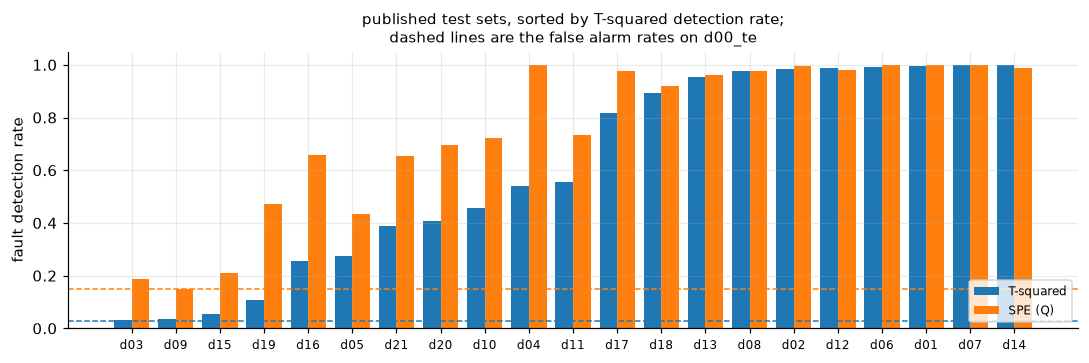

faults whose detection rate is under twice the false alarm rate on *both* statistics: [3, 9, 15]


In [4]:
order = sorted(range(1, 22), key=lambda n: pub_rows[n][0]["fault_detection_rate"])
fig, ax = plt.subplots(figsize=(10, 3.4))
x = np.arange(len(order))
ax.bar(x - 0.2, [pub_rows[n][0]["fault_detection_rate"] for n in order], 0.4,
       label="T-squared", color="tab:blue")
ax.bar(x + 0.2, [pub_rows[n][1]["fault_detection_rate"] for n in order], 0.4,
       label="SPE (Q)", color="tab:orange")
ax.axhline(pub_far["T-squared"], color="tab:blue", ls="--", lw=1.0)
ax.axhline(pub_far["SPE"], color="tab:orange", ls="--", lw=1.0)
ax.set_xticks(x)
ax.set_xticklabels(["d%02d" % n for n in order], fontsize=8)
ax.set_ylabel("fault detection rate")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, loc="lower right")
ax.set_title("published test sets, sorted by T-squared detection rate;\n"
             "dashed lines are the false alarm rates on d00_te", fontsize=10)
fig.tight_layout()
plt.show()

hard = [n for n in range(1, 22)
        if pub_rows[n][0]["fault_detection_rate"] < 2 * pub_far["T-squared"]
        and pub_rows[n][1]["fault_detection_rate"] < 2 * pub_far["SPE"]]
print("faults whose detection rate is under twice the false alarm rate on *both* "
      "statistics:", hard)

The rule in that last line is deliberately crude, and it is stated in the code rather than
in prose so that it can be argued with: a fault counts as undetected if neither statistic
manages twice its own false alarm rate. On the published data it selects exactly `d03`,
`d09` and `d15`, which is the qualitative claim from the literature, reproduced here from
the same files the literature used.

Note what it does *not* select. `d05`, `d10`, `d16`, `d19` and `d20` are all poorly
detected by T-squared, several of them below 0.4, but SPE catches them well enough that
they are clearly not invisible. That distinction is the reason both statistics are always
reported.

## Part 2: the same experiment on simulated runs

Everything above could be an artifact of how those particular files were generated. The
port can be asked the same question directly, and there is an unusually clean way to do
it: `teprob.f` carries a comment listing the exact generator seed used for each published
file. Reproducing them is not a search problem.

The scenarios below use those seeds, a 48-hour run, and the fault arriving at hour 8,
which is the layout of the published test sets. The training model is fitted to this
port's own 25-hour fault-free run at the `d00_tr` seed, so the two halves of the
comparison never share any data.

In [5]:
# teprob.f:1187-1246, the seed used to generate each published file.
# d19_te's entry ends in the letter O rather than a zero, which is harmless inside a
# Fortran comment; the intended value is used here.
TE_SEEDS = {1: 2994833239.0, 2: 2891123453.0, 3: 3420494299.0, 4: 4598956239.0,
            5: 5658678765.0, 6: 6598593453.0, 7: 7327843434.0, 8: 8943242344.0,
            9: 9343430004.0, 10: 1039839281.0, 11: 1134345551.0, 12: 2232323236.0,
            13: 3454354353.0, 14: 4545445883.0, 15: 5849489384.0, 16: 6284545932.0,
            17: 4342232344.0, 18: 5635346588.0, 19: 9090909232.0, 20: 8322308324.0}
D00_TE_SEED = 1254545354.0
D00_TR_SEED = 4243534565.0


def fault_free(hours, seed):
    return tep.Scenario.baseline(hours=hours, seed=seed)


def arriving_at(fault, hour, base):
    return tep.Scenario.from_text(
        base.to_text().replace("events=", "events=%g:start:%d" % (hour, fault)))


def observed(run):
    return run.to_numpy()[:, PUBLISHED_COLUMNS]


simulated_training = tep.Simulation(fault_free(25.0, D00_TR_SEED)).run()
model = pcamon.fit(observed(simulated_training), retain=0.90)
t2_limit = pcamon.t_squared_limit(model["k"], model["samples"], CONFIDENCE)
spe_limit = pcamon.spe_limit(model["values"][model["k"]:], CONFIDENCE)
print("simulated training: %d samples, %d components, explained %.4f"
      % (model["samples"], model["k"], model["explained"]))
print("T-squared limit %.3f   SPE limit %.3f" % (t2_limit, spe_limit))

clean_sim = tep.Simulation(fault_free(48.0, D00_TE_SEED)).run()
sim_t2, sim_spe = pcamon.statistics(model, observed(clean_sim))
sim_far = {"T-squared": float(pcamon.alarms_above(sim_t2, t2_limit).mean()),
           "SPE": float(pcamon.alarms_above(sim_spe, spe_limit).mean())}
print()
print("false alarm rate on the simulated fault-free run:")
for name, rate in sim_far.items():
    print("  %-10s %.4f  (published d00_te gave %.4f)" % (name, rate, pub_far[name]))

simulated training: 500 samples, 31 components, explained 0.9040
T-squared limit 57.019   SPE limit 10.948



false alarm rate on the simulated fault-free run:
  T-squared  0.0083  (published d00_te gave 0.0292)
  SPE        0.1333  (published d00_te gave 0.1500)


In [6]:
sims = {n: tep.Simulation(arriving_at(n, 8.0, fault_free(48.0, s)))
        for n, s in TE_SEEDS.items()}
with ThreadPoolExecutor() as pool:
    runs = dict(zip(sims, pool.map(tep.Simulation.run, sims.values())))

sim_rows = {}
print("              published            simulated          difference")
print("fault  n    T2 FDR   Q FDR     T2 FDR   Q FDR       T2      Q")
for n in range(1, 21):
    run = runs[n]
    t2, spe = pcamon.statistics(model, observed(run))
    rt = pcamon.report(pcamon.alarms_above(t2, t2_limit), ONSET, CONSECUTIVE)
    rq = pcamon.report(pcamon.alarms_above(spe, spe_limit), ONSET, CONSECUTIVE)
    sim_rows[n] = (rt, rq)
    pt, pq = pub_rows[n][0]["fault_detection_rate"], pub_rows[n][1]["fault_detection_rate"]
    print("IDV(%2d) %4d  %6.3f  %6.3f    %6.3f  %6.3f    %+6.3f %+6.3f"
          % (n, len(run), pt, pq, rt["fault_detection_rate"],
             rq["fault_detection_rate"], rt["fault_detection_rate"] - pt,
             rq["fault_detection_rate"] - pq))

              published            simulated          difference
fault  n    T2 FDR   Q FDR     T2 FDR   Q FDR       T2      Q
IDV( 1)  960   0.994   0.999     0.999   1.000    +0.005 +0.001
IDV( 2)  960   0.984   0.994     0.985   0.994    +0.001 +0.000
IDV( 3)  960   0.031   0.188     0.009   0.120    -0.022 -0.068
IDV( 4)  960   0.541   1.000     0.378   1.000    -0.164 +0.000
IDV( 5)  960   0.274   0.435     0.244   0.482    -0.030 +0.047
IDV( 6)  275   0.993   1.000     0.974   1.000    -0.019 +0.000
IDV( 7)  960   1.000   1.000     1.000   0.984    +0.000 -0.016
IDV( 8)  960   0.975   0.975     0.973   0.980    -0.002 +0.005
IDV( 9)  960   0.036   0.151     0.006   0.116    -0.030 -0.035
IDV(10)  960   0.455   0.721     0.184   0.614    -0.271 -0.107
IDV(11)  960   0.555   0.735     0.439   0.781    -0.116 +0.046
IDV(12)  960   0.988   0.981     0.973   0.964    -0.015 -0.017
IDV(13)  960   0.954   0.960     0.948   0.973    -0.006 +0.013
IDV(14)  960   1.000   0.989     0.988   

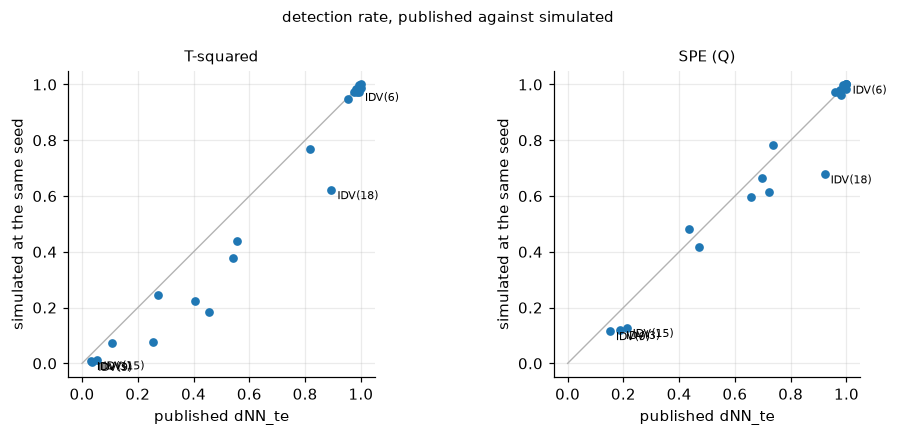

T-squared  correlation 0.9766, mean absolute difference 0.073, worst 0.272 at IDV(18)
SPE        correlation 0.9807, mean absolute difference 0.042, worst 0.243 at IDV(18)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.0))
for ax, index, name in [(axes[0], 0, "T-squared"), (axes[1], 1, "SPE (Q)")]:
    px = [pub_rows[n][index]["fault_detection_rate"] for n in range(1, 21)]
    sx = [sim_rows[n][index]["fault_detection_rate"] for n in range(1, 21)]
    ax.plot([0, 1], [0, 1], color="0.7", lw=0.9)
    ax.scatter(px, sx, s=22, color="tab:blue", zorder=3)
    for n in (3, 9, 15, 6, 18):
        ax.annotate("IDV(%d)" % n, (px[n - 1], sx[n - 1]), fontsize=7,
                    xytext=(4, -6), textcoords="offset points")
    ax.set_xlabel("published dNN_te")
    ax.set_ylabel("simulated at the same seed")
    ax.set_title(name, fontsize=10)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect("equal")
fig.suptitle("detection rate, published against simulated", fontsize=10)
fig.tight_layout()
plt.show()

pearson = lambda a, b: float(np.corrcoef(a, b)[0, 1])
for index, name in ((0, "T-squared"), (1, "SPE")):
    px = [pub_rows[n][index]["fault_detection_rate"] for n in range(1, 21)]
    sx = [sim_rows[n][index]["fault_detection_rate"] for n in range(1, 21)]
    err = np.abs(np.array(px) - np.array(sx))
    print("%-10s correlation %.4f, mean absolute difference %.3f, worst %.3f at IDV(%d)"
          % (name, pearson(px, sx), err.mean(), err.max(), int(err.argmax()) + 1))

The two data sources agree closely (correlation about 0.98 on both statistics) and they
agree on exactly the point that matters: the three faults at the bottom left of both
panels are `IDV(3)`, `IDV(9)` and `IDV(15)`.

Two things about the disagreement are worth saying, because "close enough" is not a
measurement.

The simulated T-squared rates are *systematically* a little lower than the published ones,
and the difference is largest for the faults in the middle of the range, `IDV(10)`,
`IDV(16)`, `IDV(20)` and `IDV(4)`. That is a threshold effect and not a difference in the
plant: the simulated model's own false alarm rate is 0.008 against 0.029 for the published
one, so its limit sits further out relative to the data and every rate computed against it
shifts down. The faults at the two extremes are unaffected because they are not close to
the limit in either direction.

`IDV(18)` is the largest single disagreement and has a different cause, which is worth a
section of its own.

## An aside: the published files record a plant that has already shut down

Look at the sample counts in the table above. The simulated `IDV(6)` and `IDV(18)` runs
stop early, at a few hundred samples, because the reactor pressure crossed 3000 kPa and
the plant tripped. The published `d06_te` and `d18_te` are 960 samples like everything
else.

They did not avoid the trip. The original driver keeps writing rows after the shutdown
condition is reached, and the model's derivatives are held at zero once it trips, so the
remaining rows are a plant that is not running.

In [8]:
for n in (6, 18):
    d = np.loadtxt(DATA / ("d%02d_te.dat" % n))
    freeze = int(np.argmax(d[:, 6] >= 2999.0))
    run = runs[n]
    print("d%02d_te" % n)
    print("  reactor pressure first reaches 3000 kPa at sample %d of %d" % (freeze, len(d)))
    print("  rows after that point: %d, which is %.1f%% of the 800 post-onset samples"
          % (len(d) - freeze, 100 * (len(d) - freeze) / 800))
    print("  XMEAS(1) A feed over those rows: min %.4f, max %.4f"
          % (d[freeze:, 0].min(), d[freeze:, 0].max()))
    print("  XMEAS(7) reactor pressure over those rows: min %.1f, max %.1f"
          % (d[freeze:, 6].min(), d[freeze:, 6].max()))
    print("  simulated run at the same seed: %s at sample %d (%.3f h), cause %s"
          % (run.outcome, len(run), run.tripped_hours, run.trip_cause))
    print("  the two differ by %d samples, which is %.0f minutes"
          % (abs(len(run) - 1 - freeze), 3 * abs(len(run) - 1 - freeze)))
    print()

d06_te
  reactor pressure first reaches 3000 kPa at sample 278 of 960
  rows after that point: 682, which is 85.2% of the 800 post-onset samples
  XMEAS(1) A feed over those rows: min 0.0000, max 0.0000
  XMEAS(7) reactor pressure over those rows: min 3000.0, max 3000.0
  simulated run at the same seed: tripped at sample 275 (13.784 h), cause reactor pressure high
  the two differ by 4 samples, which is 12 minutes

d18_te
  reactor pressure first reaches 3000 kPa at sample 388 of 960
  rows after that point: 572, which is 71.5% of the 800 post-onset samples
  XMEAS(1) A feed over those rows: min 0.0023, max 0.0035
  XMEAS(7) reactor pressure over those rows: min 2999.5, max 3000.1
  simulated run at the same seed: tripped at sample 390 (19.528 h), cause reactor pressure high
  the two differ by 1 samples, which is 3 minutes



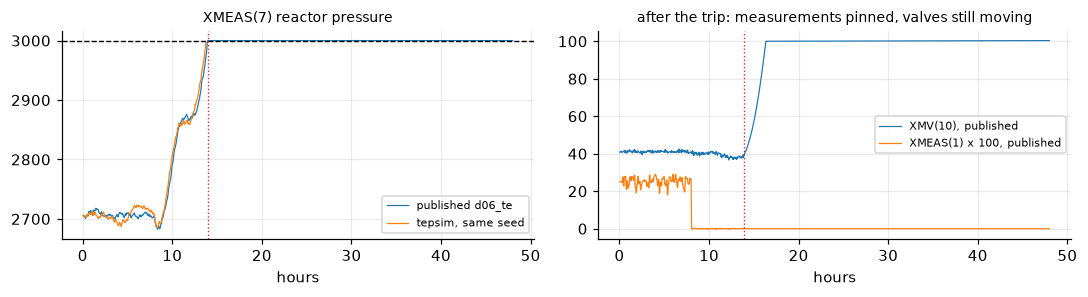

over the 682 post-trip rows of d06_te:
  the 41 XMEAS channels move by at most 2.796 in total
  the 11 XMV channels move by up to 76.25 (XMV_11_condenser_cw_flow)


In [9]:
d06 = np.loadtxt(DATA / "d06_te.dat")
freeze = int(np.argmax(d06[:, 6] >= 2999.0))
hours = np.arange(1, len(d06) + 1) * 3.0 / 60.0
run6 = runs[6]

fig, axes = plt.subplots(1, 2, figsize=(10, 2.8))
axes[0].plot(hours, d06[:, 6], lw=0.8, label="published d06_te")
axes[0].plot(run6.hours, run6.measurement(7), lw=0.8, label="tepsim, same seed")
axes[0].axhline(3000.0, color="k", ls="--", lw=0.9)
axes[0].axvline(hours[freeze], color="tab:red", ls=":", lw=0.9)
axes[0].set_title("XMEAS(7) reactor pressure", fontsize=9)
axes[0].legend(fontsize=7)
axes[1].plot(hours, d06[:, 41 + 9], lw=0.8, label="XMV(10), published")
axes[1].plot(hours, d06[:, 0] * 100, lw=0.8, label="XMEAS(1) x 100, published")
axes[1].axvline(hours[freeze], color="tab:red", ls=":", lw=0.9)
axes[1].set_title("after the trip: measurements pinned, valves still moving", fontsize=9)
axes[1].legend(fontsize=7)
for ax in axes:
    ax.set_xlabel("hours")
fig.tight_layout()
plt.show()

after = d06[freeze:]
spread = np.ptp(after, axis=0)
print("over the %d post-trip rows of d06_te:" % len(after))
print("  the 41 XMEAS channels move by at most %.4g in total" % spread[:41].max())
print("  the 11 XMV channels move by up to %.4g (%s)"
      % (spread[41:].max(), tep.channel_names()[41 + int(spread[41:].argmax())]))

The measurements are frozen and the manipulated variables are not, because the controllers
are still integrating an error signal against a plant that no longer responds. They wind
up and keep swinging the valves. For `d06_te` this accounts for 85% of the post-onset
record.

A detection rate computed over those rows is counting alarms against a constant vector,
which is trivially far from the training mean. That is not wrong exactly, since a shut down
reactor is certainly a fault condition, but it is not a measurement of a detector's ability
to notice a developing fault, and a paper reporting 0.993 for `d06` is reporting mostly
that. This port ends the run at the trip and says so through `Run.outcome`, which makes
the difference visible instead of silent.

The agreement on *when* the trip happens is the useful number here, and it is printed
above: the published files freeze and the port trips within a handful of samples of each
other, on runs of 48 simulated hours. Trajectories in this plant diverge, so the port is
validated statistically against the published data rather than sample by sample, and
matching a shutdown time this closely is a stronger agreement than that validation asks
for.

## Part 3: is it one lucky draw?

Everything so far rests on one realisation per fault. The random-walk faults in particular
could plausibly be easy on one seed and hard on another. Ten seeds per fault is 200 runs
of 48 hours, which takes a few seconds here because `run()` releases the GIL and the
ensemble is a thread pool.

In [10]:
SEEDS = [1234567891.0, 2222222223.0, 3141592653.0, 4242424243.0, 5555555555.0,
         6060606061.0, 7777777777.0, 8888888889.0, 9090909091.0, 1111111111.0]

jobs = [(n, s, tep.Simulation(arriving_at(n, 8.0, fault_free(48.0, s))))
        for n in range(1, 21) for s in SEEDS]
free_jobs = [(0, s, tep.Simulation(fault_free(48.0, s))) for s in SEEDS]
with ThreadPoolExecutor() as pool:
    finished = list(pool.map(lambda j: j[2].run(), jobs + free_jobs))

ensemble, trips = {}, {}
for (n, seed, _), run in zip(jobs + free_jobs, finished):
    t2, spe = pcamon.statistics(model, observed(run))
    onset = ONSET if n else len(t2)
    rt = pcamon.report(pcamon.alarms_above(t2, t2_limit), onset, CONSECUTIVE)
    rq = pcamon.report(pcamon.alarms_above(spe, spe_limit), onset, CONSECUTIVE)
    ensemble.setdefault(n, []).append((rt, rq))
    trips[n] = trips.get(n, 0) + (run.outcome != "completed")

print("%d runs of 48 hours" % len(finished))
print()
print("fault  trips        T-squared FDR            SPE FDR           median delay")
print("       /10       mean     sd    min-max    mean     sd       T2       Q")
for n in range(0, 21):
    rows = ensemble[n]
    t2s = np.array([r[0]["fault_detection_rate"] for r in rows])
    qs = np.array([r[1]["fault_detection_rate"] for r in rows])
    if n == 0:
        f2 = np.array([r[0]["false_alarm_rate"] for r in rows])
        fq = np.array([r[1]["false_alarm_rate"] for r in rows])
        print("free    %2d      %.3f  %.3f              %.3f  %.3f    "
              "<- false alarm rates"
              % (trips[0], f2.mean(), f2.std(ddof=1), fq.mean(), fq.std(ddof=1)))
        continue
    med = lambda ds: ("never" if all(d is None for d in ds)
                      else "%5.1f" % np.median([d for d in ds if d is not None]))
    print("%2d      %2d      %.3f  %.3f  %.2f-%.2f  %.3f  %.3f    %5s   %5s"
          % (n, trips[n], t2s.mean(), t2s.std(ddof=1), t2s.min(), t2s.max(),
             qs.mean(), qs.std(ddof=1),
             med([r[0]["detection_delay"] for r in rows]),
             med([r[1]["detection_delay"] for r in rows])))

210 runs of 48 hours

fault  trips        T-squared FDR            SPE FDR           median delay
       /10       mean     sd    min-max    mean     sd       T2       Q
free     0      0.005  0.004              0.140  0.019    <- false alarm rates
 1       0      0.994  0.002  0.99-1.00  0.999  0.001      5.5     1.0
 2       0      0.986  0.002  0.98-0.99  0.991  0.002     12.0    10.0
 3       0      0.005  0.005  0.00-0.01  0.145  0.022    123.0    73.5
 4       0      0.429  0.047  0.36-0.51  1.000  0.001      1.0     0.0
 5       0      0.229  0.023  0.18-0.26  0.416  0.035      0.0     1.0
 6      10      0.937  0.018  0.91-0.97  1.000  0.000      8.0     0.0
 7       0      1.000  0.000  1.00-1.00  0.985  0.006      0.0     0.0
 8       0      0.969  0.009  0.95-0.98  0.968  0.008     17.5    13.0
 9       0      0.006  0.006  0.00-0.02  0.147  0.022    never    93.5
10       0      0.170  0.077  0.06-0.34  0.587  0.049    168.5    18.5
11       0      0.489  0.026  0.44-0.53  

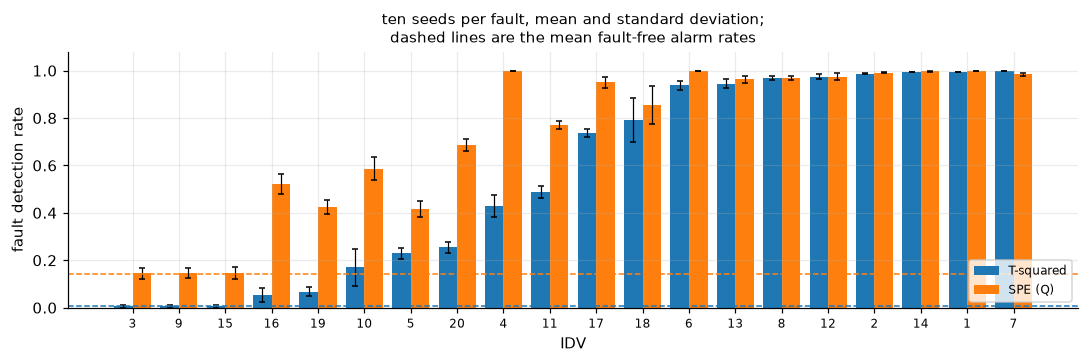

the three lowest by mean T-squared detection rate: [3, 9, 15]
their spread over ten seeds:
  IDV( 3)  0.001 to 0.015, against a fault-free rate of 0.005
  IDV( 9)  0.000 to 0.018, against a fault-free rate of 0.005
  IDV(15)  0.001 to 0.020, against a fault-free rate of 0.005


In [11]:
free_t2 = np.mean([r[0]["false_alarm_rate"] for r in ensemble[0]])
free_q = np.mean([r[1]["false_alarm_rate"] for r in ensemble[0]])
faults = list(range(1, 21))
order = sorted(faults, key=lambda n: np.mean(
    [r[0]["fault_detection_rate"] for r in ensemble[n]]))

fig, ax = plt.subplots(figsize=(10, 3.4))
x = np.arange(len(order))
for offset, index, colour, label in [(-0.2, 0, "tab:blue", "T-squared"),
                                     (0.2, 1, "tab:orange", "SPE (Q)")]:
    means = [np.mean([r[index]["fault_detection_rate"] for r in ensemble[n]]) for n in order]
    sds = [np.std([r[index]["fault_detection_rate"] for r in ensemble[n]], ddof=1)
           for n in order]
    ax.bar(x + offset, means, 0.4, yerr=sds, capsize=2, color=colour, label=label,
           error_kw={"lw": 0.8})
ax.axhline(free_t2, color="tab:blue", ls="--", lw=1.0)
ax.axhline(free_q, color="tab:orange", ls="--", lw=1.0)
ax.set_xticks(x)
ax.set_xticklabels(["%d" % n for n in order], fontsize=8)
ax.set_xlabel("IDV")
ax.set_ylabel("fault detection rate")
ax.set_ylim(0, 1.08)
ax.legend(fontsize=8, loc="lower right")
ax.set_title("ten seeds per fault, mean and standard deviation;\n"
             "dashed lines are the mean fault-free alarm rates", fontsize=10)
fig.tight_layout()
plt.show()

print("the three lowest by mean T-squared detection rate:", order[:3])
print("their spread over ten seeds:")
for n in order[:3]:
    t2s = [r[0]["fault_detection_rate"] for r in ensemble[n]]
    print("  IDV(%2d)  %.3f to %.3f, against a fault-free rate of %.3f"
          % (n, min(t2s), max(t2s), free_t2))

Ten seeds each, and the answer does not move: `IDV(3)`, `IDV(9)` and `IDV(15)` are the
three lowest, with mean T-squared detection rates of 0.005 to 0.007 against a fault-free
alarm rate of 0.005 from the same detector. They are not weakly detected, they are not
detected at all: the statistic alarms on the faulted plant at the rate it alarms on the
healthy one. The next fault up, `IDV(16)`, manages 0.052, an order of magnitude clear of
the noise floor even though 0.052 is a terrible detection rate in absolute terms.

The published files, the simulated runs at the published seeds, and a ten-seed ensemble
all give the same three.

## Part 4: why those three

This is where a port that was written from the Fortran rather than from a paper earns its
keep. The simulator can be asked what each disturbance actually does.

In [12]:
for f in tep.faults():
    if f.index in (3, 9, 15, 1, 6):
        print("IDV(%2d)  %s" % (f.index, f.shape))
        print("         published: %s" % f.published)
        print("         effect:    %s" % f.effect)
        print("         touches a model equation: %s" % f.affects_the_plant)
        if f.channels:
            print("         random walk channels: %s" % (f.channels,))
        if f.valves:
            print("         valves stuck: %s" % (f.valves,))
        print()

IDV( 1)  step
         published: A/C Feed Ratio, B Composition Constant (Stream 4)
         effect:    steps the mixed feed's A fraction down by 0.03
         touches a model equation: True

IDV( 3)  step
         published: D Feed Temperature (Stream 2)
         effect:    steps the D feed temperature up by 5 C
         touches a model equation: True

IDV( 6)  step
         published: A Feed Loss (Stream 1)
         effect:    shuts the A feed off entirely, not partially
         touches a model equation: True

IDV( 9)  random
         published: D Feed Temperature (Stream 2)
         effect:    enables the D feed temperature walk
         touches a model equation: True
         random walk channels: (3,)

IDV(15)  sticking
         published: Condenser Cooling Water Valve
         effect:    sticks valve 11; touches no equation in the model
         touches a model equation: False
         valves stuck: (11,)



Two of the three answers are right there.

`IDV(3)` steps the D feed temperature up by 5 C and `IDV(9)` enables a random walk on the
same temperature. They are the step and random versions of one disturbance, and the plant
is simply insensitive to it: the D feed is a small stream, it is heated on the way in
anyway, and the reactor has enough thermal inertia and enough control authority that five
degrees on that stream never propagates into anything a monitor is watching. Two faults on
the same insensitive input is also why they score so nearly identically.

`IDV(15)` reports `affects_the_plant = False`. A sticking fault touches no equation in the
model at all: it widens the dead band the valve command has to cross before the valve
follows. `IDV(15)` sticks valve 11, the condenser cooling water. The controller loses a
little resolution over a slow loop, and nothing else happens. (`IDV(14)`, which sticks the
*reactor* cooling water valve, is the same mechanism on a much faster and more critical
loop, and it is detected essentially perfectly. The mechanism is not the whole story: which
loop it is applied to matters more.)

The direct measurement is the distribution of the statistic itself. If a fault is
detectable, the faulted statistic has to be somewhere the fault-free statistic is not.

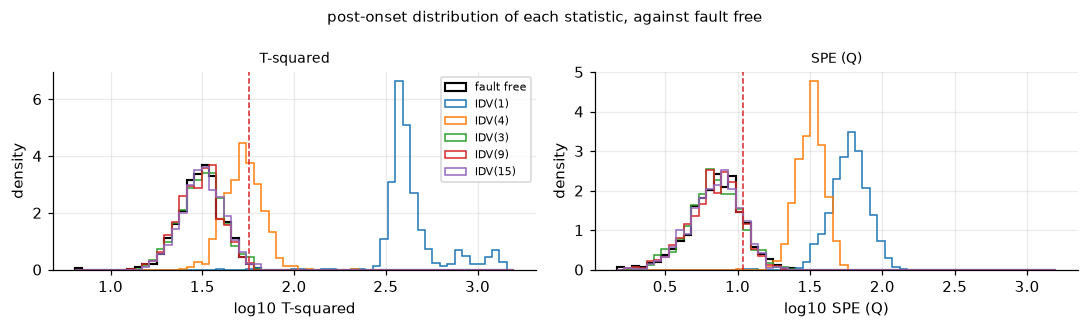

median statistic, fault free and post-onset
fault     T-squared          SPE
        median  ratio    median  ratio
free      31.33    -       7.168    -
IDV( 1)  398.04  12.70    60.596   8.45
IDV( 4)   53.26   1.70    32.486   4.53
IDV( 3)   31.75   1.01     6.863   0.96
IDV( 9)   31.18   1.00     7.085   0.99
IDV(15)   31.77   1.01     7.225   1.01


In [13]:
compare = [1, 4, 3, 9, 15]
free_stats = (sim_t2, sim_spe)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.0))
for ax, index, limit, name in [(axes[0], 0, t2_limit, "T-squared"),
                               (axes[1], 1, spe_limit, "SPE (Q)")]:
    bins = np.linspace(np.log10(max(free_stats[index].min(), 1e-3)), 3.2, 60)
    ax.hist(np.log10(free_stats[index]), bins=bins, histtype="step", lw=1.4,
            color="k", density=True, label="fault free")
    for n in compare:
        stat = pcamon.statistics(model, observed(runs[n]))[index][ONSET:]
        ax.hist(np.log10(stat), bins=bins, histtype="step", lw=1.0, density=True,
                label="IDV(%d)" % n)
    ax.axvline(np.log10(limit), color="tab:red", ls="--", lw=1.0)
    ax.set_xlabel("log10 %s" % name)
    ax.set_ylabel("density")
    ax.set_title(name, fontsize=9)
axes[0].legend(fontsize=7)
fig.suptitle("post-onset distribution of each statistic, against fault free", fontsize=10)
fig.tight_layout()
plt.show()

print("median statistic, fault free and post-onset")
print("fault     T-squared          SPE")
print("        median  ratio    median  ratio")
base_t2, base_q = np.median(free_stats[0]), np.median(free_stats[1])
print("free    %7.2f    -     %7.3f    -" % (base_t2, base_q))
for n in compare:
    a, b = pcamon.statistics(model, observed(runs[n]))
    ma, mb = np.median(a[ONSET:]), np.median(b[ONSET:])
    print("IDV(%2d) %7.2f  %5.2f   %7.3f  %5.2f" % (n, ma, ma / base_t2, mb, mb / base_q))

The histograms are the result in its plainest form. `IDV(1)` sits an order of magnitude to
the right of the fault-free curve and `IDV(4)` is clearly shifted. `IDV(3)`, `IDV(9)` and
`IDV(15)` lie on top of it: their median T-squared is within one percent of the fault-free
median, and their median SPE within four percent, on quantities whose fault-free values
span two orders of magnitude. No threshold on these two statistics separates them, because
there is nothing to separate. The faulted plant and the healthy plant are producing the
same numbers.

That is worth stating carefully, because it is easy to read this result as a criticism of
PCA. It is not. The plant really is running normally under these three disturbances. A
detector that alarmed on them would be reporting a fault that has no consequence, and the
correct behaviour for a monitoring scheme is exactly what it does. What the result actually
measures is that the Tennessee Eastman benchmark contains three conditions whose
detectability is bounded by the process, not by the method, which is what makes the
benchmark useful: it has a floor, and any paper claiming to detect all twenty is claiming
something about its false alarm rate that it has probably not measured.

## What would help

The methods the literature reaches for next are dynamic PCA, which augments each
observation with lagged copies of itself and so can see a change in the *dynamics* rather
than in the instantaneous values, and canonical variate analysis, which builds a state
space model of the fault-free data. Russell, Chiang and Braatz (2000) compares both against
static PCA on exactly these files. Both improve on `IDV(3)`, `IDV(9)` and `IDV(15)` less
than they improve elsewhere, which is the same conclusion arrived at from a different
direction.

For anyone building on this: `tepsim-stats` in this repository has `dpca` and `cva`, and
the ensemble machinery in Part 3 above is the harness you need to evaluate them, with
labels and trip outcomes carried along by the simulator instead of assumed. If what you
want is a large corpus of Tennessee Eastman runs rather than a generator for them, Rieth,
Amsel, Tran and Cook (2017) published one on Harvard Dataverse.

## References

- E. L. Russell, L. H. Chiang and R. D. Braatz, "Fault detection in industrial processes
  using canonical variate analysis and dynamic principal component analysis",
  *Chemometrics and Intelligent Laboratory Systems* **51**(1), 81-93 (2000).
  doi:10.1016/S0169-7439(00)00058-7
- L. H. Chiang, E. L. Russell and R. D. Braatz, *Fault Detection and Diagnosis in
  Industrial Systems*, Springer London (2001). doi:10.1007/978-1-4471-0347-9
- J. J. Downs and E. F. Vogel, "A plant-wide industrial process control problem",
  *Computers & Chemical Engineering* **17**(3), 245-255 (1993).
  doi:10.1016/0098-1354(93)80018-I
- C. A. Rieth, B. D. Amsel, R. Tran and M. B. Cook, "Additional Tennessee Eastman process
  simulation data for anomaly detection evaluation", Harvard Dataverse (2017).
  doi:10.7910/DVN/6C3JR1